FRAUD DETECTION SYSTEM

Total Records: 20
   user_id  amount  applications   location
0        1    1200             1      Delhi
1        2    1500             1     Mumbai
2        3    1800             2  Bangalore
3        4   50000             5      Delhi
4        5    1100             1    Chennai

RESULTS

Fraud Cases: 5/20 (25.0%)

🚨 FRAUDULENT USERS:
    user_id  amount  applications  risk_score
3         4   50000             5          65
5         6   70000             6          80
9        10   60000             4          80
12       13   80000             7          80
17       18   30000             3          30


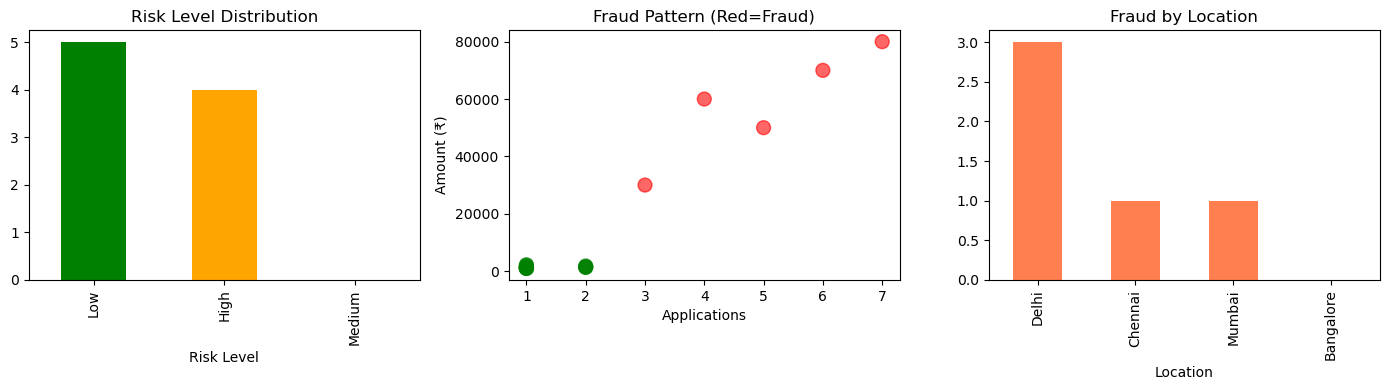


 Results saved to 'fraud_results.csv'

SUMMARY
 Total Fraud Amount: ₹290,000
 Most Affected Location: Delhi
 High Risk Users: 4


In [5]:
"""
Government Scheme Fraud Detection System
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('data.csv')
print("="*50)
print("FRAUD DETECTION SYSTEM")
print("="*50)
print(f"\nTotal Records: {len(df)}")
print(df.head())


df['amount_per_app'] = df['amount'] / df['applications']
df['high_amount'] = (df['amount'] > 50000).astype(int)
df['multiple_apps'] = (df['applications'] > 1).astype(int)


df['amount_score'] = np.where(df['amount'] > 50000, 50,
                              np.where(df['amount'] > 30000, 35, 0))
df['apps_score'] = np.where(df['applications'] >= 3, 30,
                            np.where(df['applications'] > 1, 15, 0))
df['risk_score'] = df['amount_score'] + df['apps_score']
df['risk_level'] = pd.cut(df['risk_score'], bins=[0, 30, 60, 101], 
                          labels=['Low', 'Medium', 'High'])

# ML Anomaly Detection
features = ['amount', 'applications', 'amount_per_app']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

iso_forest = IsolationForest(contamination=0.15, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X_scaled)
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})

# Final Fraud Decision
df['is_fraud'] = ((df['risk_score'] >= 60) | (df['anomaly'] == 1)).astype(int)

# Results
print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"\nFraud Cases: {df['is_fraud'].sum()}/{len(df)} ({df['is_fraud'].sum()/len(df)*100:.1f}%)")

fraud_users = df[df['is_fraud'] == 1][['user_id', 'amount', 'applications', 'risk_score']]
print("\n🚨 FRAUDULENT USERS:")
print(fraud_users)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Risk Distribution
df['risk_level'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'])
axes[0].set_title('Risk Level Distribution')
axes[0].set_xlabel('Risk Level')

# Plot 2: Amount vs Applications
colors = ['green' if x == 0 else 'red' for x in df['is_fraud']]
axes[1].scatter(df['applications'], df['amount'], c=colors, alpha=0.6, s=100)
axes[1].set_xlabel('Applications')
axes[1].set_ylabel('Amount (₹)')
axes[1].set_title('Fraud Pattern (Red=Fraud)')

# Plot 3: Fraud by Location
location_fraud = df.groupby('location')['is_fraud'].sum().sort_values(ascending=False)
location_fraud.plot(kind='bar', ax=axes[2], color='coral')
axes[2].set_title('Fraud by Location')
axes[2].set_xlabel('Location')

plt.tight_layout()
plt.show()

# Save results
df.to_csv('fraud_results.csv', index=False)
print("\n Results saved to 'fraud_results.csv'")

# Summary
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f" Total Fraud Amount: ₹{df[df['is_fraud']==1]['amount'].sum():,.0f}")
print(f" Most Affected Location: {location_fraud.index[0]}")
print(f" High Risk Users: {len(df[df['risk_level']=='High'])}")
print("="*50)

In [7]:
df.head()

,user_id,amount,applications,location,amount_per_app,high_amount,multiple_apps,amount_score,apps_score,risk_score,risk_level,anomaly,is_fraud
0,1,1200,1,Delhi,1200.0,0,0,0,0,0,NaN,0,0
1,2,1500,1,Mumbai,1500.0,0,0,0,0,0,NaN,0,0
2,3,1800,2,Bangalore,900.0,0,1,0,15,15,Low,0,0
3,4,50000,5,Delhi,10000.0,0,1,35,30,65,High,0,1
4,5,1100,1,Chennai,1100.0,0,0,0,0,0,NaN,0,0


In [8]:
df.tail()

,user_id,amount,applications,location,amount_per_app,high_amount,multiple_apps,amount_score,apps_score,risk_score,risk_level,anomaly,is_fraud
15,16,2000,1,Bangalore,2000.0,0,0,0,0,0,NaN,0,0
16,17,2200,1,Chennai,2200.0,0,0,0,0,0,NaN,0,0
17,18,30000,3,Delhi,10000.0,0,1,0,30,30,Low,1,1
18,19,1000,1,Mumbai,1000.0,0,0,0,0,0,NaN,0,0
19,20,950,1,Bangalore,950.0,0,0,0,0,0,NaN,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   user_id         20 non-null     int64   
 1   amount          20 non-null     int64   
 2   applications    20 non-null     int64   
 3   location        20 non-null     object  
 4   amount_per_app  20 non-null     float64 
 5   high_amount     20 non-null     int64   
 6   multiple_apps   20 non-null     int64   
 7   amount_score    20 non-null     int64   
 8   apps_score      20 non-null     int64   
 9   risk_score      20 non-null     int64   
 10  risk_level      9 non-null      category
 11  anomaly         20 non-null     int64   
 12  is_fraud        20 non-null     int64   
dtypes: category(1), float64(1), int64(10), object(1)
memory usage: 2.2+ KB
